# AAN Harmonic: Load Checkpoint and Compare Trajectories

This notebook loads a trained Action-Angle Network (AAN) checkpoint,
rolls out predictions from an initial state, and compares them against
the ground-truth harmonic motion dynamics.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
import jax.numpy as jnp
from flax import serialization
import matplotlib.pyplot as plt

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim

%config InlineBackend.figure_format = 'retina'

In [3]:
# # Discover available checkpoints (*.params) under results/**/
# def list_checkpoints(root='results'):
#     paths = sorted(Path(root).rglob('*.params'))
#     for i, p in enumerate(paths[-20:]):
#         print(f'{i:2d}:', p)
#     return paths

# ckpts = list_checkpoints()
# print(f'Total found: {len(ckpts)}')
# # Set your checkpoint path here (index into the printed list or absolute path).
# ckpt_index = None  # e.g., 0, 1, ...; if None, uses latest
# ckpt_path = ckpts[-1] if (ckpts and ckpt_index is None) else (ckpts[ckpt_index] if ckpt_index is not None else None)
# print('Chosen checkpoint:', ckpt_path)

In [4]:
# job_id = '860208'
# ckpt_path = f'/Users/shunsukekamiya/Desktop/1_Lab/_5_symmetric_hamiltonian/ActionAngleNetworks/results/20250919_aan_harmonic/aan_harmonic_job{job_id}.opbs/checkpoints/params_step_05000.params'
ckpt_path = '/Users/shunsukekamiya/Desktop/1_Lab/_5_symmetric_hamiltonian/ActionAngleNetworks/results/aan_harmonic/p9511dxd/aan_harmonic_job861886.opbs/checkpoints/params_step_05000.params'

In [5]:
Path(ckpt_path).exists()

True

In [6]:
# Load training config from Weights & Biases (W&B)
# This tries to infer the run from ckpt_path; override wandb_run_path if needed.
import os, json
import wandb

wandb_entity = os.environ.get('WANDB_ENTITY') or 'shunsuke-kamiya-the-university-of-tokyo'
wandb_project = os.environ.get('WANDB_PROJECT') or 'aan_harmonic'


In [7]:

# Try to infer a run hint from the checkpoint path (folder name under results/).
run_hint = None
try:
    if 'ckpt_path' in globals() and ckpt_path:
        p = Path(ckpt_path)
        parts = p.parts
        if 'results' in parts:
            idx = parts.index('results')
            if len(parts) > idx + 2:
                # e.g., results/<experiment>/<run_id_or_name>/checkpoints/...
                run_hint = parts[idx + 2]
except Exception as e:
    print('Could not infer run hint from ckpt_path:', e)
print('run_hint:', run_hint)

# Optionally specify the full run path explicitly: 'entity/project/run_id'
wandb_run_path = None  # e.g., 'my-entity/aan_harmonic/abc123'

api = wandb.Api()
run = None
try:
    if wandb_run_path:
        run = api.run(wandb_run_path)
    else:
        # Try direct ID/path using the hint
        if run_hint is not None:
            try:
                run = api.run(f'{wandb_entity}/{wandb_project}/{run_hint}')
            except Exception:
                # Fallback: search by name/id among recent runs
                runs = api.runs(f'{wandb_entity}/{wandb_project}')
                for r in runs:
                    if r.id == run_hint or r.name == run_hint:
                        run = r
                        break
        # If still not found, pick the latest run in the project
        if run is None:
            runs = api.runs(f'{wandb_entity}/{wandb_project}')
            if runs:
                run = runs[0]
except Exception as e:
    print('W&B API error:', e)

if run is None:
    print('No W&B run found. Set wandb_run_path or ensure WANDB_ENTITY/PROJECT are correct.')
    cfg = {}
else:
    cfg = dict(run.config)
    print('Loaded W&B config from:', '/'.join(run.path))
    print(json.dumps(cfg, indent=2, default=str))

# Optionally, update local variables if present in cfg (kept conservative).
def _maybe(k, default):
    return cfg.get(k, default) if isinstance(cfg, dict) else default

try:
    n = int(_maybe('n', n))
except NameError:
    n = int(_maybe('n', 2))
# You may similarly pull other fields, e.g.:
# dim_hidden = int(_maybe('dim_hidden', dim_hidden))
# num_gsblocks = int(_maybe('num_gsblocks', num_gsblocks))
# type_polar = _maybe('type_polar', type_polar)
# activation = _maybe('activation', activation)
# theta_predictor = _maybe('theta_predictor', theta_predictor)
# mlp_res_connection = bool(_maybe('mlp_res_connection', mlp_res_connection))
# dim_hidden_list = _maybe('dim_hidden_list', dim_hidden_list)
# T = int(_maybe('T', T))
# dt = float(_maybe('delta_t', dt))


run_hint: p9511dxd


wandb: Currently logged in as: shunsuke-kamiya (shunsuke-kamiya-the-university-of-tokyo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded W&B config from: shunsuke-kamiya-the-university-of-tokyo/aan_harmonic/p9511dxd
{
  "T": 1000,
  "n": 2,
  "lr": 0.001,
  "seed": 42,
  "A_max": 2,
  "A_min": 1,
  "alpha": 0.1,
  "m_max": 3,
  "m_min": 1,
  "k_pair": 0.005,
  "k_wall": 0.01,
  "delta_t": 1,
  "save_dir": "./results/aan_harmonic/p9511dxd",
  "log_every": 100,
  "num_steps": 5000,
  "activation": "sigmoid",
  "batch_size": 100,
  "dim_hidden": 64,
  "num_params": 7445,
  "save_every": 1000,
  "test_split": 0.5,
  "type_polar": "canonical",
  "delta_t_max": 10,
  "single_step": true,
  "train_split": 0.1,
  "normalize_qp": false,
  "num_gsblocks": 20,
  "dim_hidden_list": [
    32,
    32,
    32
  ],
  "experiment_name": "aan_harmonic",
  "test_time_jumps": [
    1,
    2,
    5,
    10,
    20,
    50
  ],
  "theta_predictor": "gradient",
  "mlp_res_connection": false
}


In [8]:
# Model configuration (must match training)
n = cfg['n']                     # number of oscillators (dimensions per q or p)
dim_hidden = cfg['dim_hidden']          # hidden size inside GS blocks / MLP
num_gsblocks = cfg['num_gsblocks']         # number of GS blocks (flow layers)
type_polar = cfg['type_polar']  # 'canonical' or 'normal'
activation = cfg['activation']    # 'relu' | 'tanh' | 'sigmoid'
theta_predictor = cfg['theta_predictor']  # 'gradient' or 'mlp'
mlp_res_connection = cfg['mlp_res_connection']    # residual in theta MLP (if used)
dim_hidden_list = cfg['dim_hidden_list'] # only used if theta_predictor='gradient'

# Rollout configuration
T = cfg['T']               # number of rollout steps
dt = cfg['delta_t']              # time delta per step (must match training)
seed = cfg['seed']
rng = jax.random.PRNGKey(seed)

# Build model
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=dim_hidden,
    num_gsblocks=num_gsblocks,
    type_polar=type_polar,
    activation=getattr(jax.nn, activation),
    theta_predictor=theta_predictor,
    mlp_res_connection=mlp_res_connection,
    dim_hidden_list=dim_hidden_list,
)
q0 = jnp.zeros((1, n))
p0 = jnp.zeros((1, n))
vars0 = model.init(rng, q0, p0, jnp.asarray(dt))
params0 = vars0['params']
print('Model initialized. Params leaves:', len(jax.tree_util.tree_leaves(params0)))

# Load parameters if a checkpoint is chosen
data = Path(ckpt_path).read_bytes()
loaded_params = serialization.from_bytes(params0, data)
params = loaded_params
print('Loaded params from', ckpt_path)


Model initialized. Params leaves: 88
Loaded params from /Users/shunsukekamiya/Desktop/1_Lab/_5_symmetric_hamiltonian/ActionAngleNetworks/results/aan_harmonic/p9511dxd/aan_harmonic_job861886.opbs/checkpoints/params_step_05000.params


In [9]:
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict
@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParams) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = np.diag(1.0 / np.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = np.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [11]:
test_seed = cfg['seed']#1234
sim_params = sample_harmonic_params(
    n=cfg['n'],
    m_range=(cfg['m_min'], cfg['m_max']),
    k_wall=cfg['k_wall'],
    k_pair=cfg['k_pair'],
    A_range=(cfg['A_min'], cfg['A_max']),
    seed=test_seed
)
t, q_true, p_true, aux = simulate_coupled_1d_harmonic(sim_params, num_steps=cfg['T'], dt=cfg['delta_t'])
# Initial state for rollout
q_init = q_true[:1]  # shape (1, n)
p_init = p_true[:1]  # shape (1, n)


In [12]:
print(f'GT shapes: q {q_true.shape}, p {p_true.shape}')

GT shapes: q (1000, 2), p (1000, 2)


In [13]:
q_init.shape

(1, 2)

In [14]:
# Roll out AAN predictions for T steps with step size dt
def step_fn(carry, _):
    q_cur, p_cur = carry
    q_nxt, p_nxt, _, _ = model.apply({'params': params}, q_cur, p_cur, jnp.asarray(dt), train=False)
    return (q_nxt, p_nxt), (q_nxt, p_nxt)

(_, _), (q_seq, p_seq) = jax.lax.scan(step_fn, (q_init, p_init), None, length=T-1)
q_seq = jnp.squeeze(q_seq, axis=1) # (T-1, n)
p_seq = jnp.squeeze(p_seq, axis=1) # (T-1, n)
q_pred = jnp.concatenate([q_init, q_seq], axis=0) # (T, n)
p_pred = jnp.concatenate([p_init, p_seq], axis=0) # (T, n)
# q_pred = jnp.concatenate([q_init, q_seq], axis=0)
# p_pred = jnp.concatenate([p_init, p_seq], axis=0)

# remove potential singleton batch
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim == 3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim == 3 else p_pred
print('Pred shapes:', q_pred.shape, p_pred.shape)

Pred shapes: (1000, 2) (1000, 2)


In [19]:
T

1000

In [22]:
times = np.arange(T) * dt

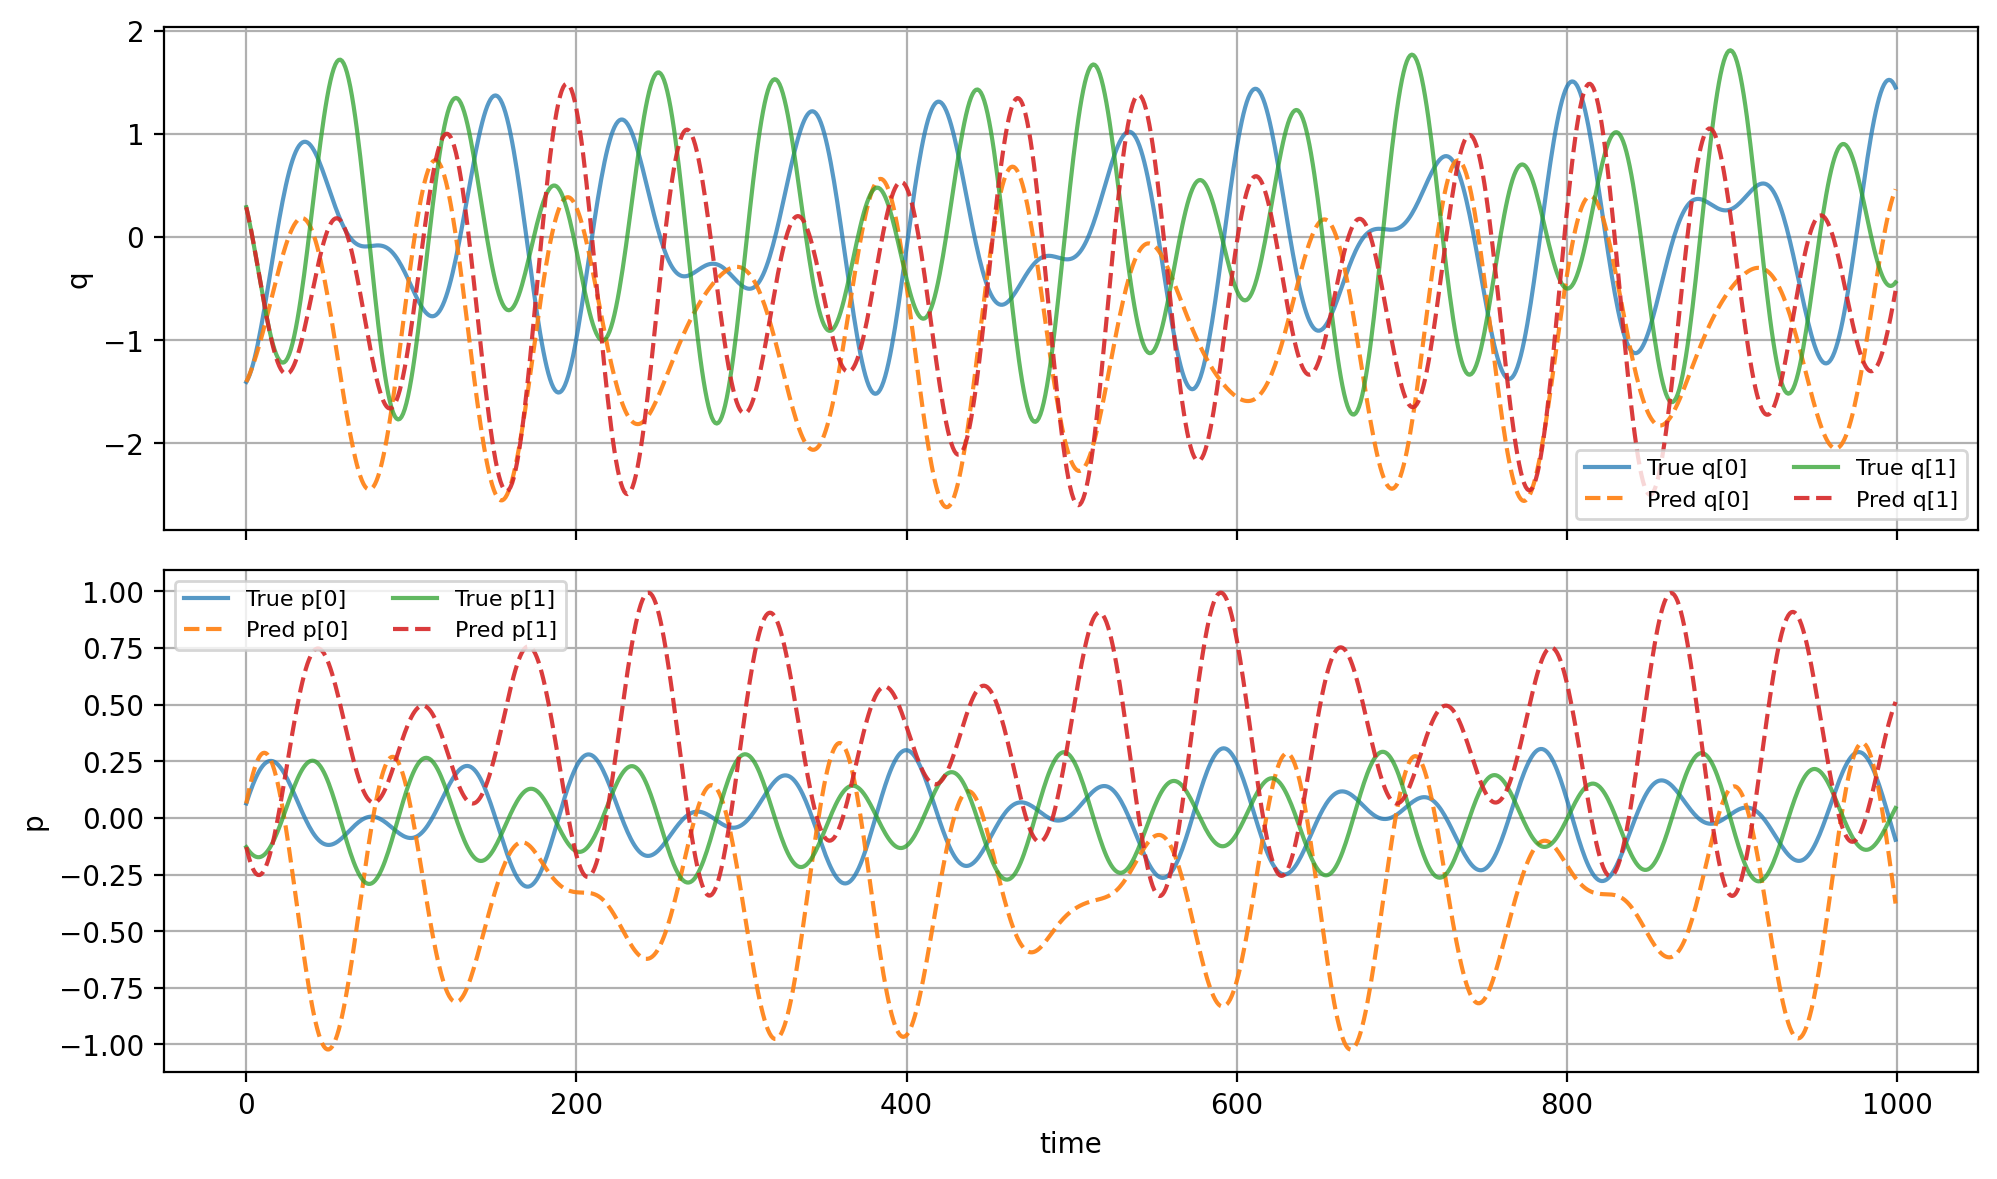

In [23]:
# Plot trajectories: true vs predicted
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = np.asarray(times)

for i in range(n):
    axes[0].plot(t, np.asarray(q_true)[:, i], label=f'True q[{i}]', alpha=0.75)
    axes[0].plot(t, np.asarray(q_pred)[:, i], '--', label=f'Pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(n):
    axes[1].plot(t, np.asarray(p_true)[:, i], label=f'True p[{i}]', alpha=0.75)
    axes[1].plot(t, np.asarray(p_pred)[:, i], '--', label=f'Pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

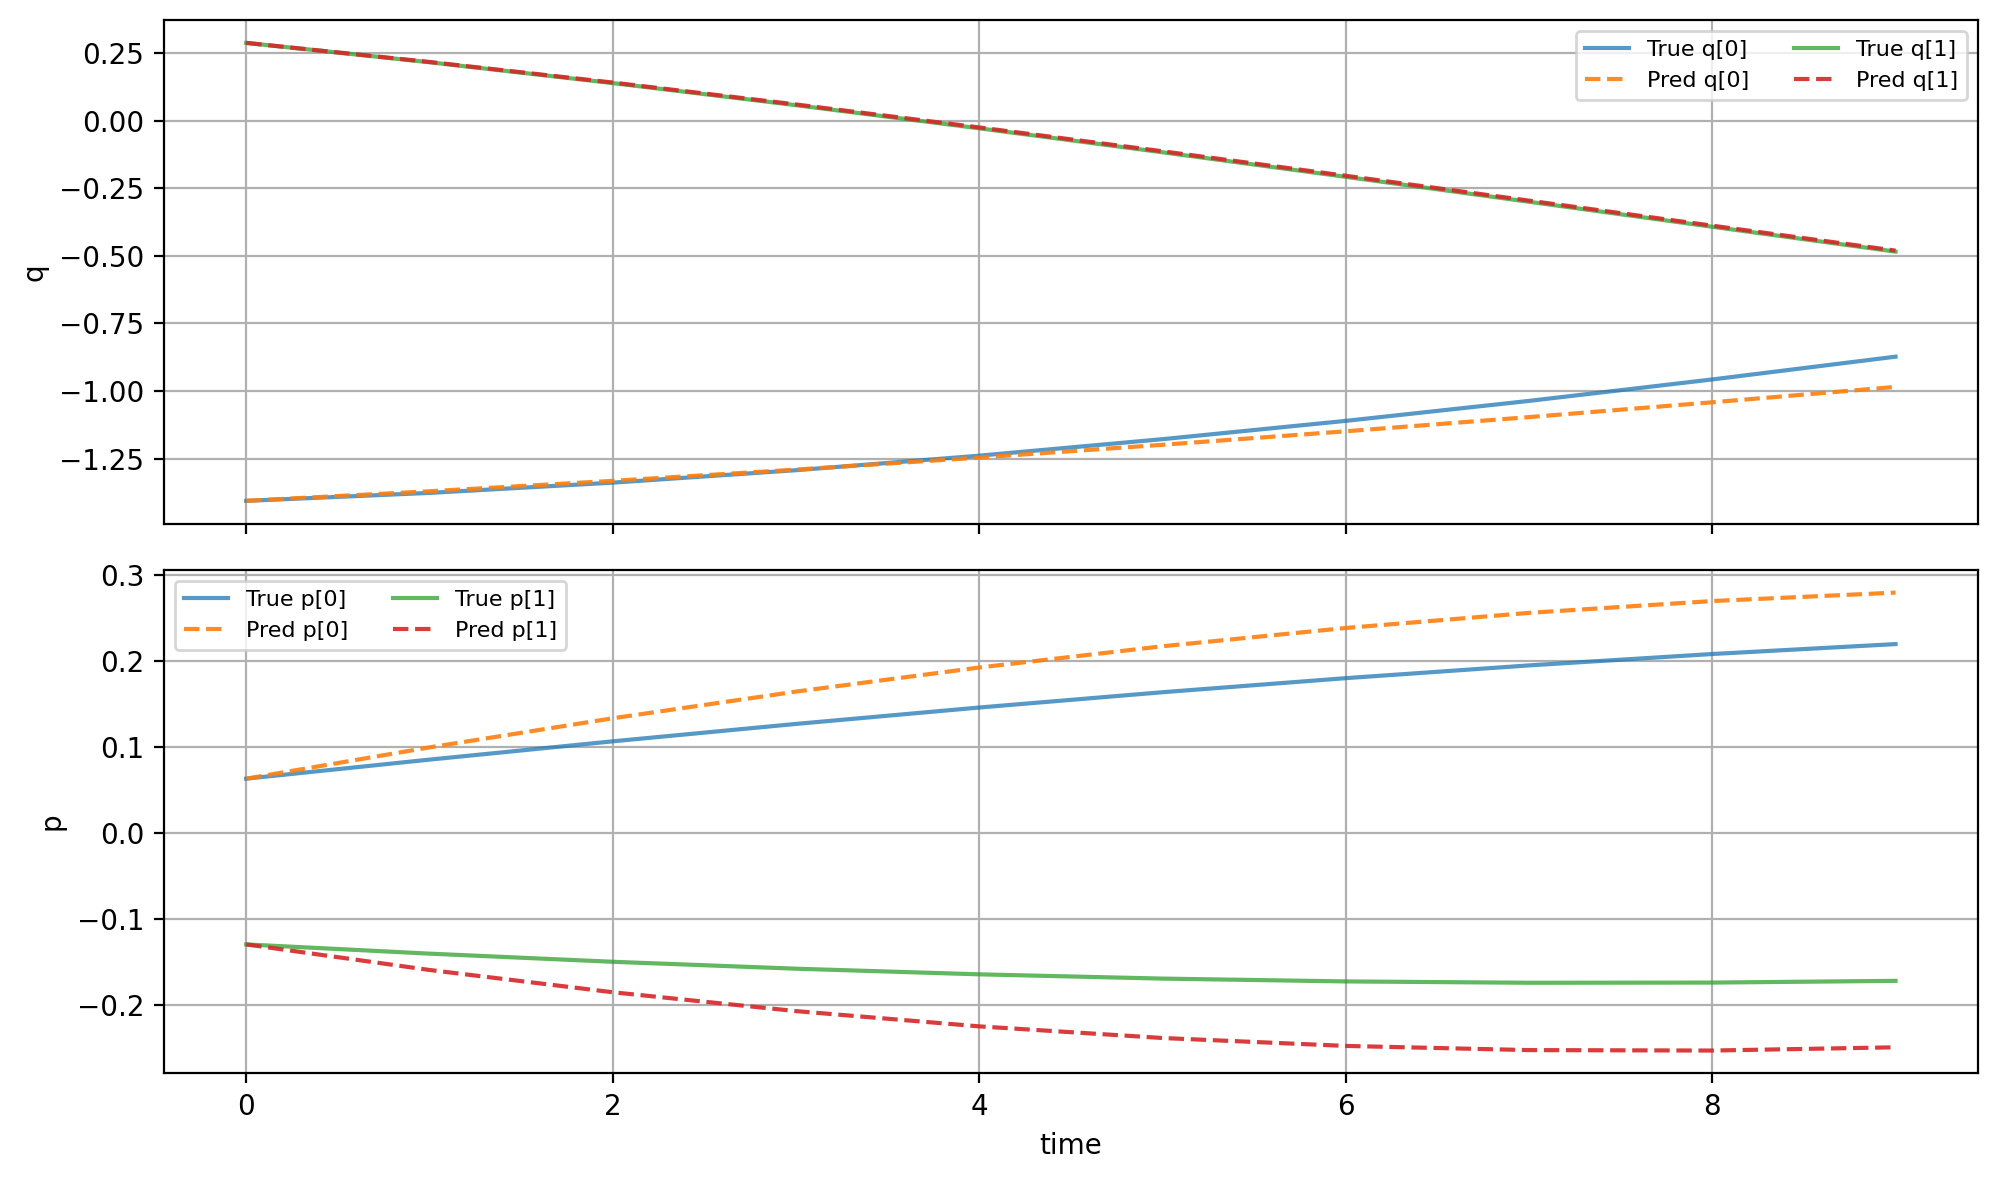

In [24]:
# Plot trajectories: true vs predicted
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = np.asarray(times)

steps_to_plot = 10


for i in range(n):
    axes[0].plot(t[:steps_to_plot], np.asarray(q_true)[:steps_to_plot, i], label=f'True q[{i}]', alpha=0.75)
    axes[0].plot(t[:steps_to_plot], np.asarray(q_pred)[:steps_to_plot, i], '--', label=f'Pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(n):
    axes[1].plot(t[:steps_to_plot], np.asarray(p_true)[:steps_to_plot, i], label=f'True p[{i}]', alpha=0.75)
    axes[1].plot(t[:steps_to_plot], np.asarray(p_pred)[:steps_to_plot, i], '--', label=f'Pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()